<a href="https://colab.research.google.com/github/ajitesh68/machine-learning-practice-/blob/main/TF002_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

INRODUCTION TO REGRESSION WITH NEURAL NETWORKS


there are many definition for a regression prblm but in our case we are going other combination of variables , even shorter .... predicting a number

In [1]:
#IMPORT tensorflow
import tensorflow as tf
print(tf.__version__)

2.18.0


Creating data to view and fit

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#crate features
x = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0], dtype=float)

#create labels
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0], dtype=float)

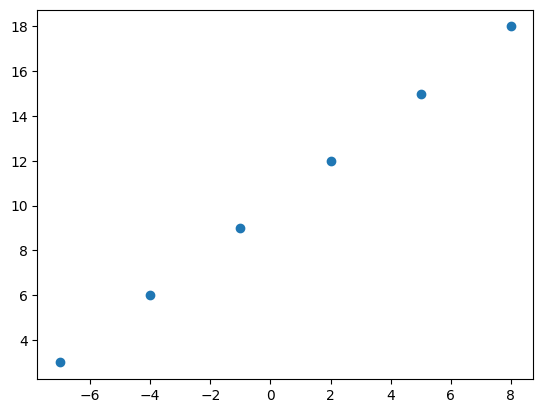

In [3]:
plt.scatter(x,y)

In [4]:
y == x+10

array([ True,  True,  True,  True,  True,  True])

Input and Output shapes

In [5]:
#create a demo tensor for our houseing prediction problem
house_info = tf.constant(["bedroom","bathroom","garage"])
house_price = tf.constant([939700])

In [6]:
house_info, house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700], dtype=int32)>)

In [7]:
x[0], y[0]

(np.float64(-7.0), np.float64(3.0))

In [8]:
x[1], y[1]

(np.float64(-4.0), np.float64(6.0))

In [9]:
input_shape = x[0].shape
output_shape = y[0].shape
input_shape, output_shape

((), ())

In [10]:
x[0].ndim

0

In [11]:
x[0] , y[0]

(np.float64(-7.0), np.float64(3.0))

In [12]:
#convert numpy arrays into tensors with dtype float 32
x = tf.cast(tf.constant(x), dtype=tf.float32)
y = tf.cast(tf.constant(y), dtype=tf.float32)

In [13]:
x , y


(<tf.Tensor: shape=(6,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18.], dtype=float32)>)

In [14]:
input_shape = x[0].shape
output_shape = y[0].shape
input_shape, output_shape
#there is no shape as there is single value or scalar value

(TensorShape([]), TensorShape([]))

Steps in creating a model with TensorFlow

1. Creating a model - define the i/p and o/p layers , as well as the hidden layers of a deep learning model

2. Comppiling a model - define a loss fnc (in other words, the fnc which tells our model how wrong our model how wrong it is ) and optimizer (tells our model how to improve the patterns its learning ) and evaluation metrics (what we can use to interpret the performance of our model).

3. Fitting a model- letting the model try to find patterns between x & y (features and labels)

In [15]:
#Set random seed
tf.random.set_seed

#1. create a model using the Sequential API
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

#2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])# mae are short for mean absolute error
              #sgd is short for stochastic gradient descent

#3. Fit the model
model.fit(tf.expand_dims(x, axis=-1), y, epochs=5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 13.5885 - mae: 13.5885
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - loss: 13.5038 - mae: 13.5038
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - loss: 13.4191 - mae: 13.4191
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step - loss: 13.3344 - mae: 13.3344
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - loss: 13.2496 - mae: 13.2496


In [16]:
#check out x and y
x , y

(<tf.Tensor: shape=(6,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18.], dtype=float32)>)

In [17]:
#Try add make prediction using our model
import numpy as np

y_pred = model.predict(np.array([[17.0]]))  # double brackets to make it 2D
print(y_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step
[[-22.0895]]


In [18]:
y_pred + 10   # mae: 9.8731 hence we our adding 10 to y predicted

array([[-12.0895]], dtype=float32)

Improving our model

Steps we can improve our model, by altering the steps we took to create a model

1. Create a model -- here we might add more layersm increase the number of hidden units (all called neurons) within each of the hidden layers , change the activation fnc of each layer

2. "Compiling a model" -- here we might change the optimization fnc or perhaps the "learning rate" of the optimization fnc

3. "Fitting a model" -- here we might fit a model for more ""epochs"" (leave it training for longer) or on more data (give the model more example to learn from).

In [19]:
#higher the learning rate the more model pushes to improve at every step and lower the learning rate
# the model take lower steps to improve the model

In [20]:
import numpy as np

# If x was like this:
# x = [1.0, 2.0, 3.0, 4.0]

# Do this instead:
x = np.array([[1.0], [2.0], [3.0], [4.0]])
y = np.array([2.0, 4.0, 6.0, 8.0])  # keep y as 1D


In [21]:
#Lets rebuild our model

#1. Create the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

#2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

#3. Fit the model
model.fit(x, y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 1.7110 - mae: 1.7110
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 1.6385 - mae: 1.6385
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 1.5660 - mae: 1.5660
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 1.4935 - mae: 1.4935
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - loss: 1.4210 - mae: 1.4210
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - loss: 1.3485 - mae: 1.3485
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - loss: 1.2760 - mae: 1.2760
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - loss: 1.2035 - mae: 1.2035
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - loss: 1.1310 - mae: 1.1310
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - loss: 1.0585 - mae: 1.0585
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - loss: 0.9860 - mae: 0.9860
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - loss: 0.9135 - mae: 0.9135
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [22]:
#Remind ourselves of the data
x,y


(array([[1.],
        [2.],
        [3.],
        [4.]]),
 array([2., 4., 6., 8.]))

In [23]:
#let 's see if our model's prediction has improved
model.predict(np.array([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


array([[33.954872]], dtype=float32)

In [24]:
#Let's see if we can make another to improve our model

#create the model (this time with an extra hidden layer with 100 hidden units)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(50,activation= None),
    tf.keras.layers.Dense(1)
])

#2 . Compile the model
model.compile(loss ="mae",
              optimizer= tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=["mae"])


#fit the model
model.fit(x,y,epochs=100)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 5.2376 - mae: 5.2376
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 5.1832 - mae: 5.1832
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 5.1288 - mae: 5.1288
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 5.0744 - mae: 5.0744
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 5.0199 - mae: 5.0199
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 4.9654 - mae: 4.9654
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 4.9109 - mae: 4.9109
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 4.8563 - mae: 4.8563
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 4.8017 - mae: 4.8017
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 4.7470 - mae: 4.7470
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 4.6922 - mae: 4.6922
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 4.6373 - mae: 4.6373
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step 

In [25]:
#Remind ourselves of the data
x,y

(array([[1.],
        [2.],
        [3.],
        [4.]]),
 array([2., 4., 6., 8.]))

In [26]:
#let 's see if our model's prediction has improved
model.predict(np.array([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


array([[30.594402]], dtype=float32)

Common Ways To Improve the Deep Model

1. Adding The Layers
2. Increase the number of hidden units
3. Change the activation fnc
4. Change the optimization fnc
5. Change the learning rate(potentially the most imp hyperparameter of many diff neural networks)
6. Fitting more data
7. Fitting for longer



Evaluating a Model

In practice, a typical workflow you will go through while building a neural networks is:

Build a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it....

When it comes to evaluation.... there are 3 words you should memorize:

"Visualize, Visualize , Visualize"

It's good idea to visualize:

* the data we are working with? What does it look like ?
* The model itself - What does our model look like?
* The training of a model how does a model perform while learn
* The prediction of a model how does a prediction of a model line up against the ground truth ( the original labels)?

In [27]:
#Make a bigger dataset  most probably for a good prediction or training

x  = tf.range(-100,100,4)
x

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96], dtype=int32)>

In [28]:
#we want our model to learn this formula
y = x + 10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

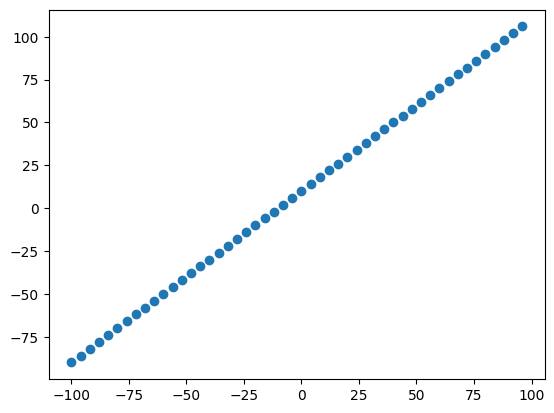

In [29]:
#visulaize our data
import matplotlib.pyplot as plt
plt.scatter(x,y)


# There are 3 sets ..........

**Training set** :- The model learn from this data , typically contains 80% of the the total dataset available

**Validation dataset** :- The model gets tuned on this data , typically contains 10%-15% of the the total dataset available

**Testing dataset** :- The model gets test on this data , typically contains 10%-15% of the the total dataset available

In [30]:
len(x)

50

In [31]:
#Split the data into training and testing dataset

x_train = x[:40]#80% of the data is been given for training from 1-40     #first 40 are training samples
x_test = x[40:]#20% of the data is been given for testing from 41-50

y_train = x[:40]
y_test = x[40:]

In [32]:
len(x_test), len(x_train), len(y_test), len(y_train)

(10, 40, 10, 40)

**Visualizing the predictions**
Now we've got a trained model, let's visualize some predictions.

To visualize predictions, it's always a good idea to plot them against the ground truth labels.

Often you'll see this in the form of y_test vs. y_pred (ground truth vs. predictions).

First, we'll make some predictions on the test data (X_test), remember the model has never seen the test data.

In [33]:
# Make predictions
y_preds = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


In [34]:

# View the predictions
y_preds

array([[105.43705 ],
       [112.399155],
       [119.36127 ],
       [126.32337 ],
       [133.28548 ],
       [140.24757 ],
       [147.2097  ],
       [154.1718  ],
       [161.1339  ],
       [168.09602 ]], dtype=float32)

In [35]:
def plot_predictions(train_data=x_train,
                     train_labels=y_train,
                     test_data=x_test,
                     test_labels=y_test,
                     predictions=y_preds):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))
  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", label="Training data")
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", label="Testing data")
  # Plot the predictions in red (predictions were made on the test data)
  plt.scatter(test_data, predictions, c="r", label="Predictions")
  # Show the legend
  plt.legend();

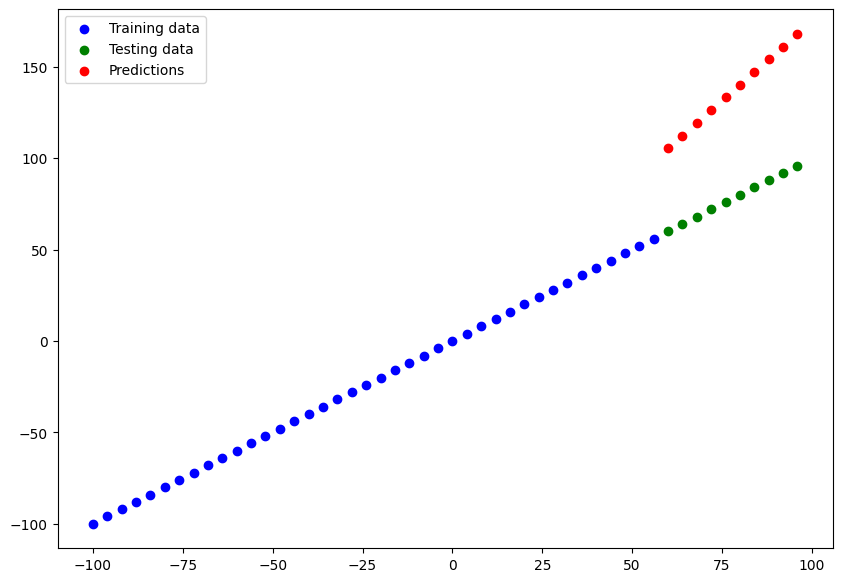

In [36]:
plot_predictions(train_data=x_train,
                 train_labels=y_train,
                 test_data=x_test,
                 test_labels=y_test,
                 predictions=y_preds)

In [37]:
def mae(y_test, y_pred):
  """
  Calculuates mean absolute error between y_test and y_preds.
  """
  return tf.metrics.MAE(y_test,y_pred)

def mse(y_test, y_pred):
  """
  Calculates mean squared error between y_test and y_preds.
  """
  return tf.metrics.MSE(y_test,y_pred)

**Running experiments to improve a model**

After seeing the evaluation metrics and the predictions your model makes, it's likely you'll want to improve it.

Again, there are many different ways you can do this, but 3 of the main ones are:

**Get more data** - get more examples for your model to train on (more opportunities to learn patterns).

**Make your model larger (use a more complex model)** - this might come in the form of more layers or more hidden units in each layer.

**Train for longer** - give your model more of a chance to find the patterns in the data.

Since we created our dataset, we could easily make more data but this isn't always the case when you're working with real-world datasets.

So let's take a look at how we can improve our model using 2 and 3.

To do so, we'll build 3 models and compare their results:

model_1 - same as original model, 1 layer, trained for 100 epochs.
model_2 - 2 layers, trained for 100 epochs.
model_3 - 2 layers, trained for 500 epochs.
**Build model_1**

In [38]:
# Set random seed
tf.random.set_seed(42)

# Replicate original model
model_1 = tf.keras.Sequential([
  tf.keras.layers.Dense(1)
])

# Compile the model
model_1.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['mae'])

# Fit the model
model_1.fit(tf.expand_dims(x_train, axis=-1), y_train, epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 17.5762 - mae: 17.5762 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 14.4261 - mae: 14.4261
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 12.3458 - mae: 12.3458
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 10.2654 - mae: 10.2654
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 8.1851 - mae: 8.1851
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 6.1047 - mae: 6.1047
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 4.0244 - mae: 4.0244
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 2.5403 - mae: 2.5403
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 4.0242 - mae: 4.0242
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 2.5404 - mae: 2.5404
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 4.0241 - mae: 4.0241
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 2.5405 - mae: 2.5405
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


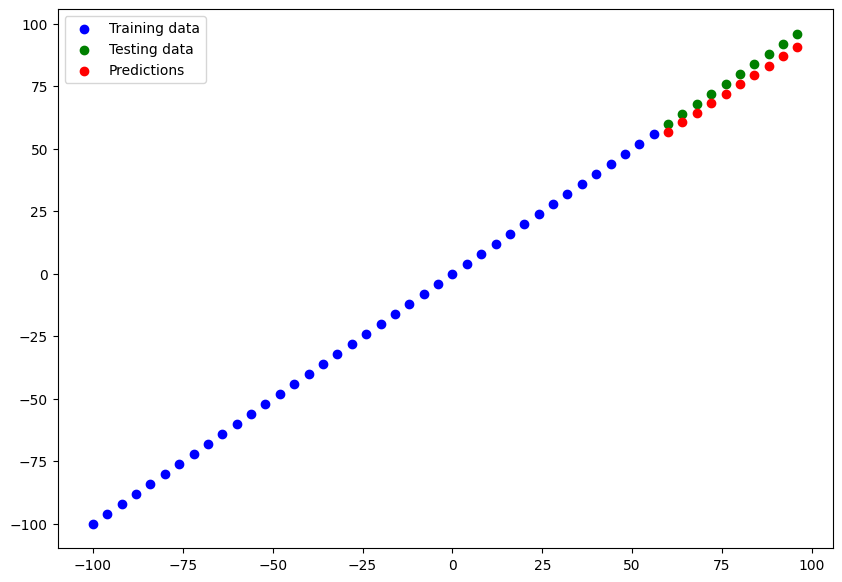

In [39]:
# Make and plot predictions for model_1
y_preds_1 = model_1.predict(x_test)
plot_predictions(predictions=y_preds_1)

In [40]:
tf.constant(y_preds_1) , tf.squeeze(y_preds_1)

#squeeze reduce the dimension by 1

(<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
 array([[56.78838 ],
        [60.57425 ],
        [64.36012 ],
        [68.14599 ],
        [71.93186 ],
        [75.717735],
        [79.5036  ],
        [83.289474],
        [87.07535 ],
        [90.86121 ]], dtype=float32)>,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([56.78838 , 60.57425 , 64.36012 , 68.14599 , 71.93186 , 75.717735,
        79.5036  , 83.289474, 87.07535 , 90.86121 ], dtype=float32)>)

In [41]:

# Calculate model_1 metrics
mae_1 = mae(y_test, y_preds_1.squeeze()).numpy()
mse_1 = mse(y_test, y_preds_1.squeeze()).numpy()
mae_1, mse_1

(np.float32(4.1752024), np.float32(17.810589))

In [42]:
# Calculate model_1 metrics
mae_1 = mae(y_test, y_preds_1).numpy()
mse_1 = mse(y_test, y_preds_1).numpy()
mae_1, mse_1

(array([3.2116203, 3.4257507, 3.6398773, 3.8540115, 4.068138 , 4.2822647,
        4.496399 , 4.7105255, 4.924652 , 5.1387863], dtype=float32),
 array([10.314506, 11.735768, 13.248707, 14.853405, 16.549747, 18.337791,
        20.217604, 22.18905 , 24.2522  , 26.407125], dtype=float32))

**model_2 **

In [43]:
tf.random.set_seed(42)

#build the model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
]
)

#compile the model

model_2.compile(loss=tf.keras.losses.mae,
                metrics=["mse"],
                optimizer=tf.keras.optimizers.SGD())

#fit the model
# model_2.fit(tf.expand_dims(x_train, axis=-1), y_train , epochs=100)

x_train = tf.reshape(x_train, (-1, 1))  # Reshape (40,) → (40, 1)
model_2.fit(x_train, y_train, epochs=100)
# Your model expects input with an extra dimension (e.g., (batch, timesteps, channels)), but x_train is missing it
# Working Code: tf.expand_dims(x_train, axis=-1) adds the missing dimension (e.g., from (1000, 10) to (1000, 10, 1)).

#(Example: If your first layer is Conv1D, it needs 3D input—so your fix is correct!)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 44.8232 - mse: 2973.6760 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 35.6805 - mse: 1946.2338
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 31.9340 - mse: 1569.2909
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 37.1515 - mse: 1973.7212
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 8.1901 - mse: 191.7387
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 15.2296 - mse: 325.9511
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 18.6599 - mse: 516.0190
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 22.4529 - mse: 762.9129
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 30.1708 - mse: 1287.4301
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 4.2691 - mse: 150.0210
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 16.4900 - mse: 384.2554
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 19.8460 - mse: 618.3413
Epoch 13/

In [44]:
model_2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (136.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [45]:
x_train.shape

TensorShape([40, 1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


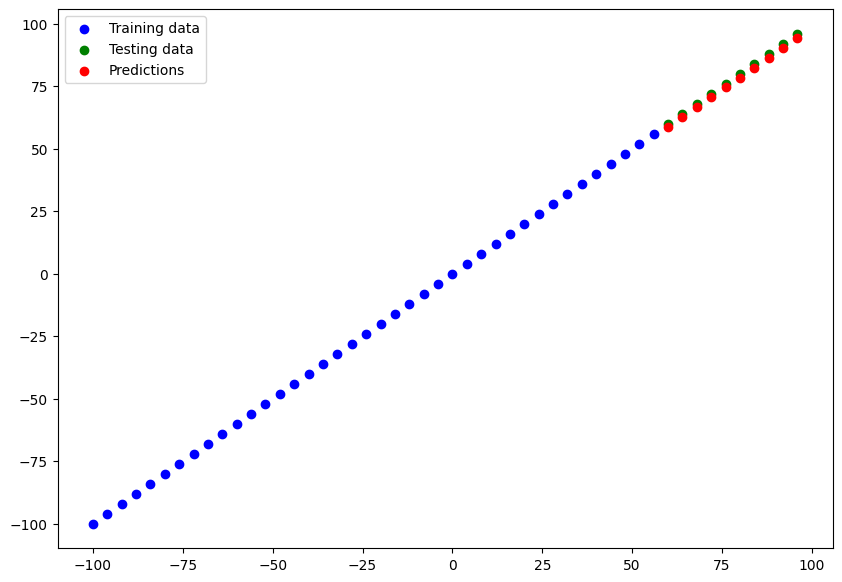

In [46]:
y_preds_2 = model_2.predict(x_test)
plot_predictions(predictions=y_preds_2)

#red dots should be plot close to the green dots in order to claim a better model

In [47]:
# Calculate model_2 metrics
mae_2 = mae(y_test, y_preds_2)
mse_2 = mse(y_test, y_preds_2)
mae_2, mse_2

(<tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([1.1479607, 1.222126 , 1.2962875, 1.3704529, 1.4446106, 1.5187759,
        1.5929413, 1.667099 , 1.741272 , 1.8154297], dtype=float32)>,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([1.3178136, 1.493592 , 1.6803614, 1.878141 , 2.0868998, 2.3066804,
        2.537462 , 2.7792192, 3.0320282, 3.295785 ], dtype=float32)>)

Model_3

 2 layers and 500 epochs

In [48]:
tf.random.set_seed(42)

#build the model
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
]
)

#compile the model

model_3.compile(loss=tf.keras.losses.mae,
                metrics=["mae"],
                optimizer=tf.keras.optimizers.SGD())

#fit the model
# model_2.fit(tf.expand_dims(x_train, axis=-1), y_train , epochs=100)

x_train = tf.reshape(x_train, (-1, 1))  # Reshape (40,) → (40, 1)
model_3.fit(x_train, y_train, epochs=500)

Epoch 1/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 32.4426 - mae: 32.4426 
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 26.2222 - mae: 26.2222
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 23.8542 - mae: 23.8542 
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 23.5031 - mae: 23.5031
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 24.7966 - mae: 24.7966
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 34.0769 - mae: 34.0769 
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 6.5158 - mae: 6.5158 
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 15.6375 - mae: 15.6375
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 19.1092 - mae: 19.1092
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 23.3522 - mae: 23.3522
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 26.8379 - mae: 26.8379
Epoch 12/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 6.3814 - mae: 6.3814
Epoch 13/500
2/2 ━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


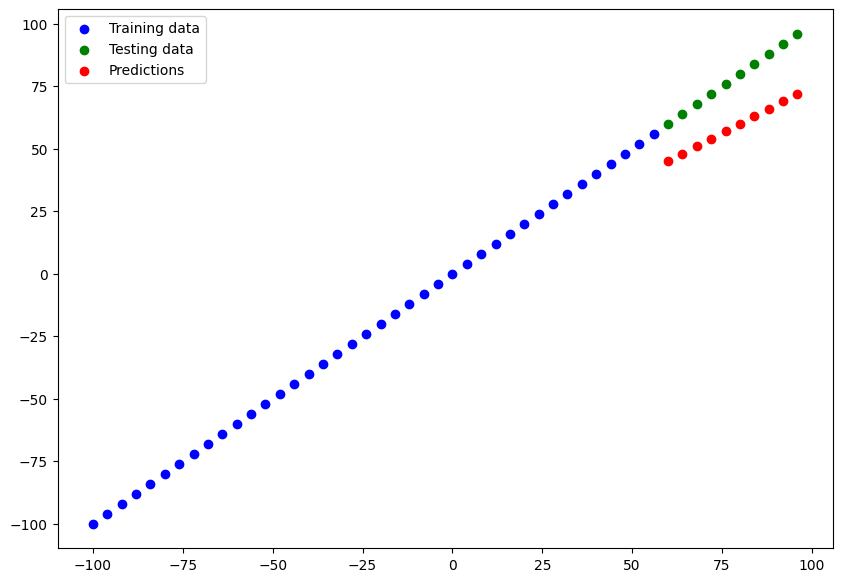

In [49]:
y_preds_3 = model_3.predict(x_test)
plot_predictions(predictions=y_preds_3)

In [50]:
# Calculate model_2 metrics
mae_3 = mae(y_test, y_preds_3)
mse_3 = mse(y_test, y_preds_3)
mae_3, mse_3

(<tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([15.083553, 16.082817, 17.082073, 18.081333, 19.080593, 20.07986 ,
        21.07912 , 22.078377, 23.077637, 24.076897], dtype=float32)>,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([227.51358, 258.657  , 291.7972 , 326.9346 , 364.06903, 403.2008 ,
        444.3293 , 487.4547 , 532.57733, 579.69696], dtype=float32)>)

**Comparing results**

Now we've got results for 3 similar but slightly different results, let's compare them

In [51]:
import tensorflow as tf

def to_numpy_compatible(value):
    # Convert input to TensorFlow tensor first
    tensor_value = tf.convert_to_tensor(value)
    # Now safely call .numpy()
    return tensor_value.numpy()

model_results = [
    ["model_1", to_numpy_compatible(mae_1), to_numpy_compatible(mse_1)],
    ["model_2", to_numpy_compatible(mae_2), to_numpy_compatible(mse_2)],
    ["model_3", to_numpy_compatible(mae_3), to_numpy_compatible(mse_3)]
]

In [52]:
import pandas as pd
all_results = pd.DataFrame(model_results, columns=["model", "mae", "mse"])
all_results


,model,mae,mse
0,model_1,"[3.2116203, 3.4257507, 3.6398773, 3.8540115, 4...","[10.314506, 11.735768, 13.248707, 14.853405, 1..."
1,model_2,"[1.1479607, 1.222126, 1.2962875, 1.3704529, 1....","[1.3178136, 1.493592, 1.6803614, 1.878141, 2.0..."
2,model_3,"[15.083553, 16.082817, 17.082073, 18.081333, 1...","[227.51358, 258.657, 291.7972, 326.9346, 364.0..."


🔑 Note: One of your main goals should be to minimize the time between your experiments. The more experiments you do, the more things you'll figure out which don't work and in turn, get closer to figuring out what does work. Remember the machine learning practitioner's motto: "experiment, experiment, experiment".


**Saving a model**

Once you've trained a model and found one which performs to your liking, you'll probably want to save it for use elsewhere (like a web application or mobile device).

You can save a TensorFlow/Keras model using model.save().

There are two ways to save a model in TensorFlow:

**The SavedModel format (default).**
**The HDF5 format**.

The main difference between the two is the SavedModel is automatically able to save custom objects (such as special layers) without additional modifications when loading the model back in.

Which one should you use?

It depends on your situation but the SavedModel format will suffice most of the time.

Both methods use the same method call.

In [53]:
model_1.save('best_model.keras')  # Native Keras format (lightweight)

In [54]:

# Check it out - outputs a protobuf binary file (.pb) as well as other files
!ls best_model.keras

best_model.keras


Now saving a model using hdf5 format

In [55]:

# Save a model using the HDF5 format
model_2.save("best_model_HDF5_format.h5") # note the addition of '.h5' on the end

In [56]:
# Check it out
!ls best_model_HDF5_format.h5

best_model_HDF5_format.h5


**Loading a model**


We can load a saved model using the load_model() method.

Loading a model for the different formats (SavedModel and HDF5) is the same (as long as the pathnames to the particular formats are correct

In [57]:
# Load a model from the SavedModel format
loaded_saved_model = tf.keras.models.load_model("best_model.keras")
loaded_saved_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [58]:
model_1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [59]:
model_1_preds = model_1.predict(x_test)
loaded_saved_model_preds = loaded_saved_model.predict(x_test)
model_1_preds == loaded_saved_model_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

How to download your file from google colab

In [60]:
# Download the model (or any file) from Google Colab
from google.colab import files
files.download("best_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**A larger example**


Alright, we've seen the fundamentals of building neural network regression models in TensorFlow.

Let's step it up a notch and build a model for a more feature rich dataset.

More specifically we're going to try predict the cost of medical insurance for individuals based on a number of different parameters such as, age, sex, bmi, children, smoking_status and residential_region.

To do, we'll leverage the pubically available Medical Cost dataset available from Kaggle and hosted on GitHub.

🔑 Note: When learning machine learning paradigms, you'll often go through a series of foundational techniques and then practice them by working with open-source datasets and examples. Just as we're doing now, learn foundations, put them to work with different problems. Every time you work on something new, it's a good idea to search for something like "problem X example with Python/TensorFlow" where you substitute X for your problem.

In [61]:
import tensorflow as tf
import pandas as pd

import matplotlib.pyplot as plt


In [62]:


# Read in the insurance dataset
insurance = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv")

In [63]:

# Check out the insurance dataset
insurance.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


We're going to have to turn the non-numerical columns into numbers (because a neural network can't handle non-numerical inputs).

To do so, we'll use the get_dummies() method in pandas.

It converts categorical variables (like the sex, smoker and region columns) into numerical variables using one-hot encoding.

In [64]:
insurance_one_hot = pd.get_dummies(insurance)
insurance_one_hot.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


In [65]:
# Replace True with 1 and False with 0
insurance_one_hot = insurance_one_hot.replace({True: 1, False: 0})

/tmp/ipython-input-65-3517674497.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  insurance_one_hot = insurance_one_hot.replace({True: 1, False: 0})


In [66]:
insurance_one_hot.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,0,0,1,0,0,0,1
1,18,33.770,1,1725.55230,0,1,1,0,0,0,1,0
2,28,33.000,3,4449.46200,0,1,1,0,0,0,1,0
3,33,22.705,0,21984.47061,0,1,1,0,0,1,0,0
4,32,28.880,0,3866.85520,0,1,1,0,0,1,0,0


In [67]:
x = insurance_one_hot.drop("charges", axis=1)
y = insurance_one_hot["charges"]

In [68]:
y.head()


,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [69]:
x.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,1,0,0,1,0,0,0,1
1,18,33.770,1,0,1,1,0,0,0,1,0
2,28,33.000,3,0,1,1,0,0,0,1,0
3,33,22.705,0,0,1,1,0,0,1,0,0
4,32,28.880,0,0,1,1,0,0,1,0,0


In [70]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=40)

len(x_train), len(x_test), len(x)

(1070, 268, 1338)

In [71]:
x_train

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
737,26,23.700,2,0,1,1,0,0,0,0,1
369,18,30.400,3,0,1,1,0,1,0,0,0
284,52,31.200,0,1,0,1,0,0,0,0,1
1302,25,20.800,1,1,0,1,0,0,0,0,1
958,43,34.960,1,0,1,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
1330,57,25.740,2,1,0,1,0,0,0,1,0
1016,19,24.605,1,1,0,1,0,0,1,0,0
165,47,28.215,4,0,1,1,0,1,0,0,0
7,37,27.740,3,1,0,1,0,0,1,0,0


In [72]:
#build a neural network (sort of like model_2)
tf.random.set_seed(42)

#create a model
insurance_model = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

#compile the model
insurance_model.compile(loss=tf.keras.losses.mae,
                         optimizer=tf.keras.optimizers.SGD(),
                         metrics=["mae"])

#fit the model
insurance_model.fit(x_train, y_train, epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9503.8301 - mae: 9503.8301
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7480.8994 - mae: 7480.8994
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7435.1255 - mae: 7435.1255 
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7635.5244 - mae: 7635.5244
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7584.3916 - mae: 7584.3916
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7606.1675 - mae: 7606.1675
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7545.6011 - mae: 7545.6011 
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7525.8213 - mae: 7525.8213 
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7558.1562 - mae: 7558.1562
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7566.5225 - mae: 7566.5225 
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7490.6416 - mae: 7490.6416
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/s

In [73]:
insurance_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133 (536.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [74]:
insurance_model.evaluate(x_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 7643.9351 - mae: 7643.9351


[7631.93115234375, 7631.93115234375]

We'll try 3 things:

Increasing the number of layers (2 -> 3).
Increasing the number of units in each layer (except for the output layer).
Changing the optimizer (from SGD to Adam).
Everything else will stay the same.

In [83]:
#build a neural network (sort of like model_2)
tf.random.set_seed(42)

#create a model
insurance_model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

#compile the model
insurance_model_2.compile(loss=tf.keras.losses.mae,
                         optimizer=tf.keras.optimizers.Adam(), #Adam works but SGD doesnt
                         metrics=["mae"])

#fit the model
history = insurance_model_2.fit(x_train, y_train, epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 12730.0586 - mae: 12730.0586
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12599.3975 - mae: 12599.3975
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12316.5654 - mae: 12316.5654
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 11743.8408 - mae: 11743.8408
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10736.8145 - mae: 10736.8145
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9325.4033 - mae: 9325.4033
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7891.2676 - mae: 7891.2676
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7070.2144 - mae: 7070.2144
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6904.4614 - mae: 6904.4614
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6881.8740 - mae: 6881.8740
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6858.3677 - mae: 6858.3677
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s

In [84]:
insurance_model_2.evaluate(x_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5234.3413 - mae: 5234.3413  


[5092.40478515625, 5092.40478515625]

Much better! Using a larger model and the Adam optimizer results in almost half the error as the previous model.

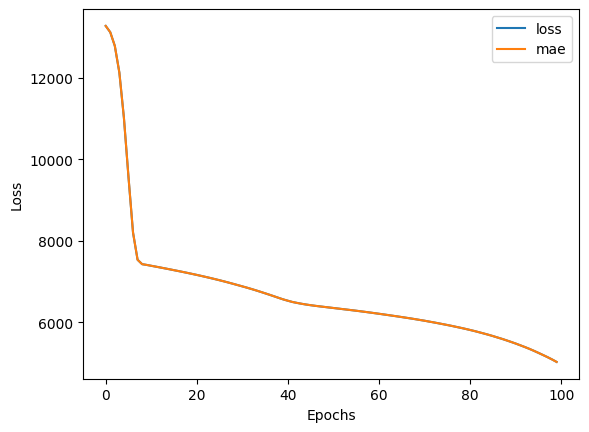

In [85]:
#Plot History (also known as loss curve)
pd.DataFrame(history.history).plot()
plt.ylabel("Loss")
plt.xlabel("Epochs");

From this, it looks like our model's loss (and MAE) were both still decreasing (in our case, MAE and loss are the same, hence the lines in the plot overlap eachother).

What this tells us is the loss might go down if we try training it for longer

In [86]:
# Try training for a little longer (100 more epochs)
history_2 = insurance_model_2.fit(x_train, y_train, epochs=100, verbose=0)

In [87]:
insurance_model_2.evaluate(x_test,y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4104.4863 - mae: 4104.4863


[3827.346435546875, 3827.346435546875]

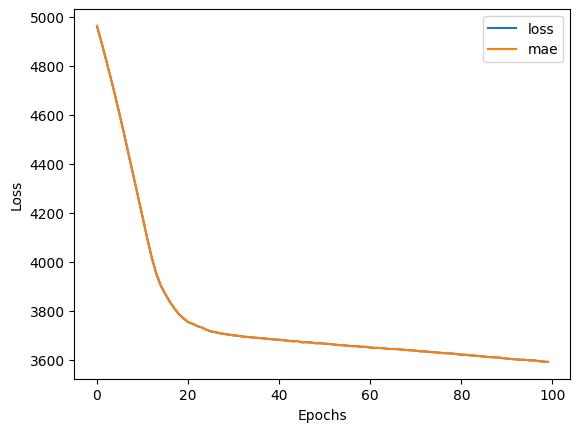

In [90]:
#Plot History (also known as loss curve)
pd.DataFrame(history_2.history).plot()
plt.ylabel("Loss")
plt.xlabel("Epochs");

**Preprocessing data (normalization and standardization)**

**Feature scaling:**

Normalizing data (making sure all values are between 0 and 1). This is done by subtracting the minimum value then dividing by the maximum value minus the minimum. This is also referred to as min-max scaling.

Standardization (making sure all values have a mean of 0 and a variance of 1). This is done by subtracting the mean value from the target feature and then dividing it by the standard deviation